# Climate variability: CESM3 / MOM6 experiment comparison

Modes of internal climate variability for a set of coupled and forced
experiments: SST variability and its leading EOF (El Nino / ENSO-like
pattern), and the North Atlantic Oscillation (NAO). The shared `Experiment`
class lives in `experiment.py` so it can be reused across notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Figures**

1. SST variability (detrended, deseasonalised std).
2. El Nino (leading EOF of SST variability).
3. NAO (North Atlantic Oscillation): leading EOF of North Atlantic sea-level
   pressure anomalies.

The NAO is an atmospheric mode, so it only exists for the **coupled**
experiments (no interactive atmosphere in the forced/ocean-only runs); those
panels correctly show "no data".

Heavy quantities are computed once through the `Experiment` class (methods
`compute_*`, reading the raw model history) and cached as
`<folder>/<name>_<metric>.nc`; the plotting cells only read those files.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cftime
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.


In [3]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())

# Column order: GM (left), bANN (center), bANN_uANN (right)
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

print('\nInitialized:', exp_names)


[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [4]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}


# 1. SST variability (detrended, deseasonalised std)

Maps of sea-surface temperature *variability*. For each experiment `thetao` is
read from the z-coordinate history (`*.mom6.h.z.*`), the uppermost level is kept
as SST, and over the standard averaging window the series at each grid point is
(1) linearly detrended (`a + b t` removed), (2) deseasonalised (monthly
climatology removed), and (3) reduced to its temporal standard deviation
(`Experiment.compute_sst_std`).

- **Left column:** GM absolute std.
- **Two right columns:** response (`experiment - GM`).

Observational reference SST variability to be added later.


In [ ]:
# Compute (and cache) the detrended, deseasonalised SST std for every
# experiment. Reads raw z-coordinate history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_sst_std()
    except Exception as e:
        print(f'{name} skipped ({e})')


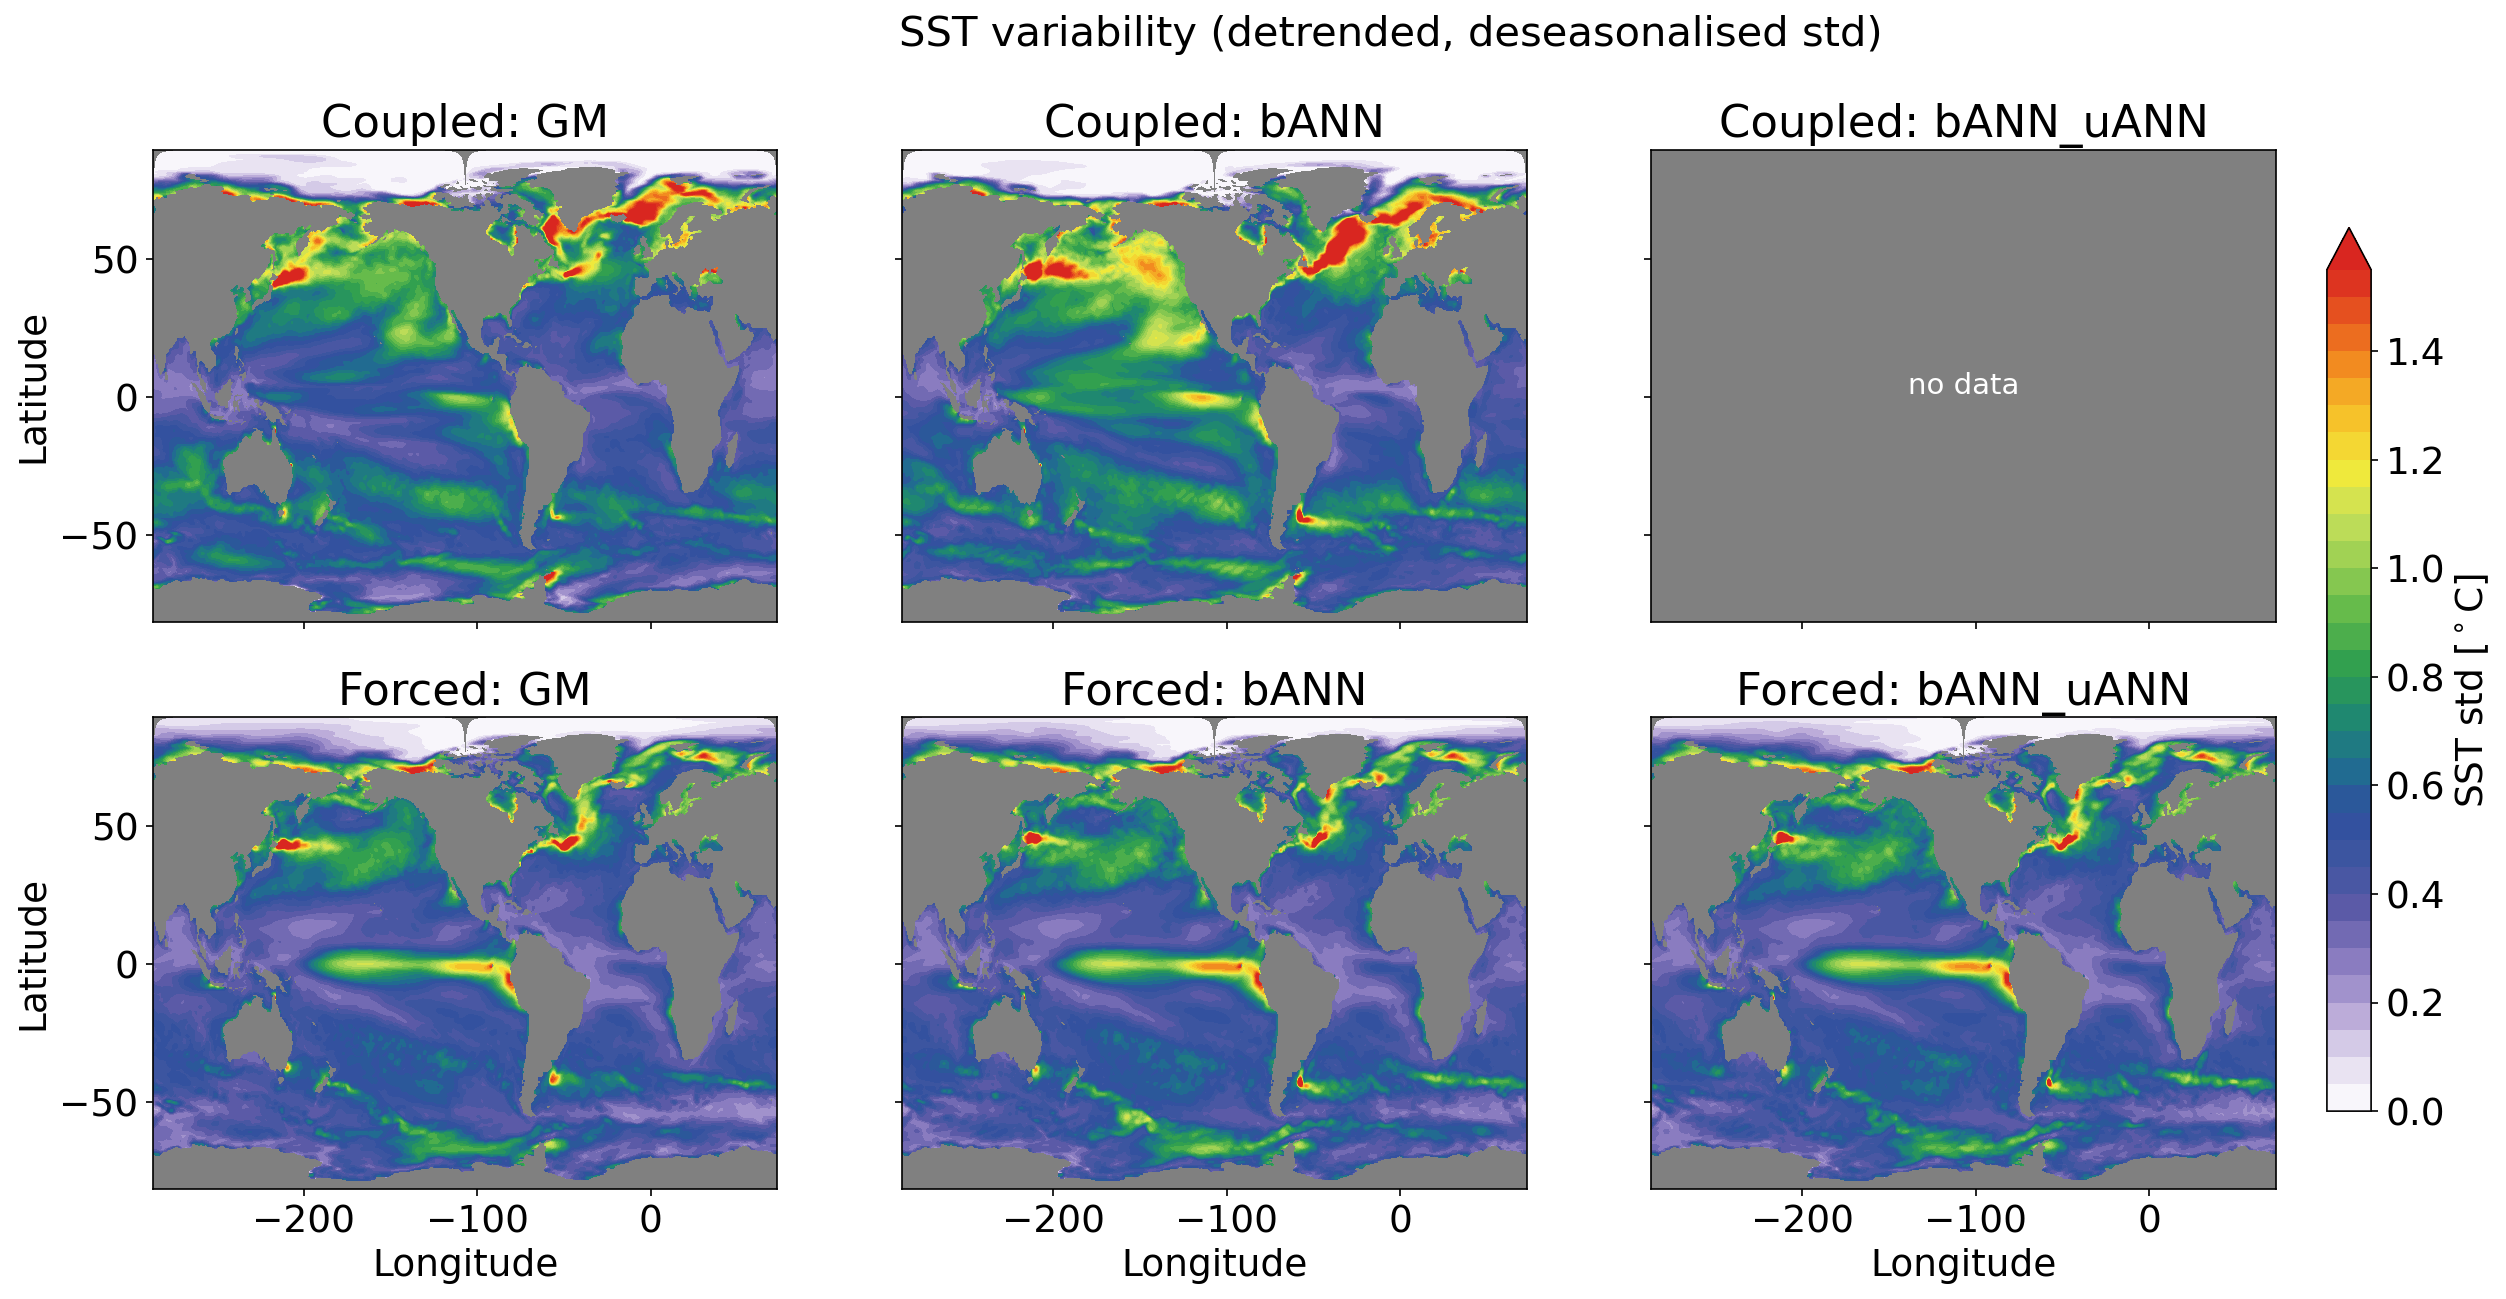

In [4]:
# SST variability (absolute std only): every panel shows the detrended,
# deseasonalised SST std for that experiment. Rows = regime, columns =
# GM / bANN / bANN_uANN. Single shared sequential colorbar.

# NCL-style White-Violet-Blue-Green-Yellow-Orange-Red palette.
from matplotlib.colors import LinearSegmentedColormap
WhViBlGrYeOrRe = LinearSegmentedColormap.from_list('WhViBlGrYeOrRe', [
    '#ffffff', '#e3dcef', '#b6a5d6', '#8a7cc0', '#5d5aa8',
    '#3f56a0', '#2f4f9e', '#1f6f8f', '#1f8a6e', '#2f9e4f',
    '#5fb84a', '#93cd52', '#c6e05a', '#f2ea3a', '#f6c22a',
    '#f39320', '#e85a1f', '#d92620',
])

SST_STD_LEVELS = np.arange(0.0, 1.6, 0.05)        # degC, absolute std

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf_abs = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            std = exps[name].sst_std()
            cf_abs = ax.contourf(grd.geolon, grd.geolat, std,
                                 levels=SST_STD_LEVELS,
                                 cmap=WhViBlGrYeOrRe, extend='max')
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf_abs is not None:
    fig.colorbar(cf_abs, ax=axes, label=r'SST std [$^\circ$C]',
                 extend='max', shrink=0.85, pad=0.02)
fig.suptitle(r'SST variability (detrended, deseasonalised std)', fontsize=20)
plt.show()


# 2. El Nino (leading EOF of SST variability)

Leading Empirical Orthogonal Function of the same detrended, deseasonalised
SST anomalies used for the SST std (Section 1). The decomposition **accounts
for the grid-cell area**: each anomaly is weighted by $\sqrt{A_i}$ before the
SVD, so the spatial patterns are orthogonal with respect to the inner product
on the sphere,

$$\langle u, v\rangle = \sum_i A_i\, u_i\, v_i .$$

The physical patterns $e_k = v_k / \sqrt{A_i}$ then satisfy
$\sum_i A_i\, e_k(i)\, e_l(i) = \delta_{kl}$. The leading principal component
(PC1) is standardised to unit variance, and the map (`sst_eof1`) is the
regression of the anomalies onto PC1 (degC per +1 std of PC1). Both the pattern
and the PC1 time series are cached to `<folder>/<name>_sst_eof1.nc`; the panel
titles show the fraction of area-weighted variance explained.

Globally this decomposition is dominated by the tropical Pacific ENSO
pattern, hence "El Nino" here.

The first cell computes/caches per experiment; the second plots the six EOF1
maps and the PC1 time series.


In [ ]:
# Compute (and cache) the leading area-weighted EOF / PC1 of the detrended,
# deseasonalised SST for every experiment. Reads raw z-coordinate history
# -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_sst_eof1()
    except Exception as e:
        print(f'{name} skipped ({e})')


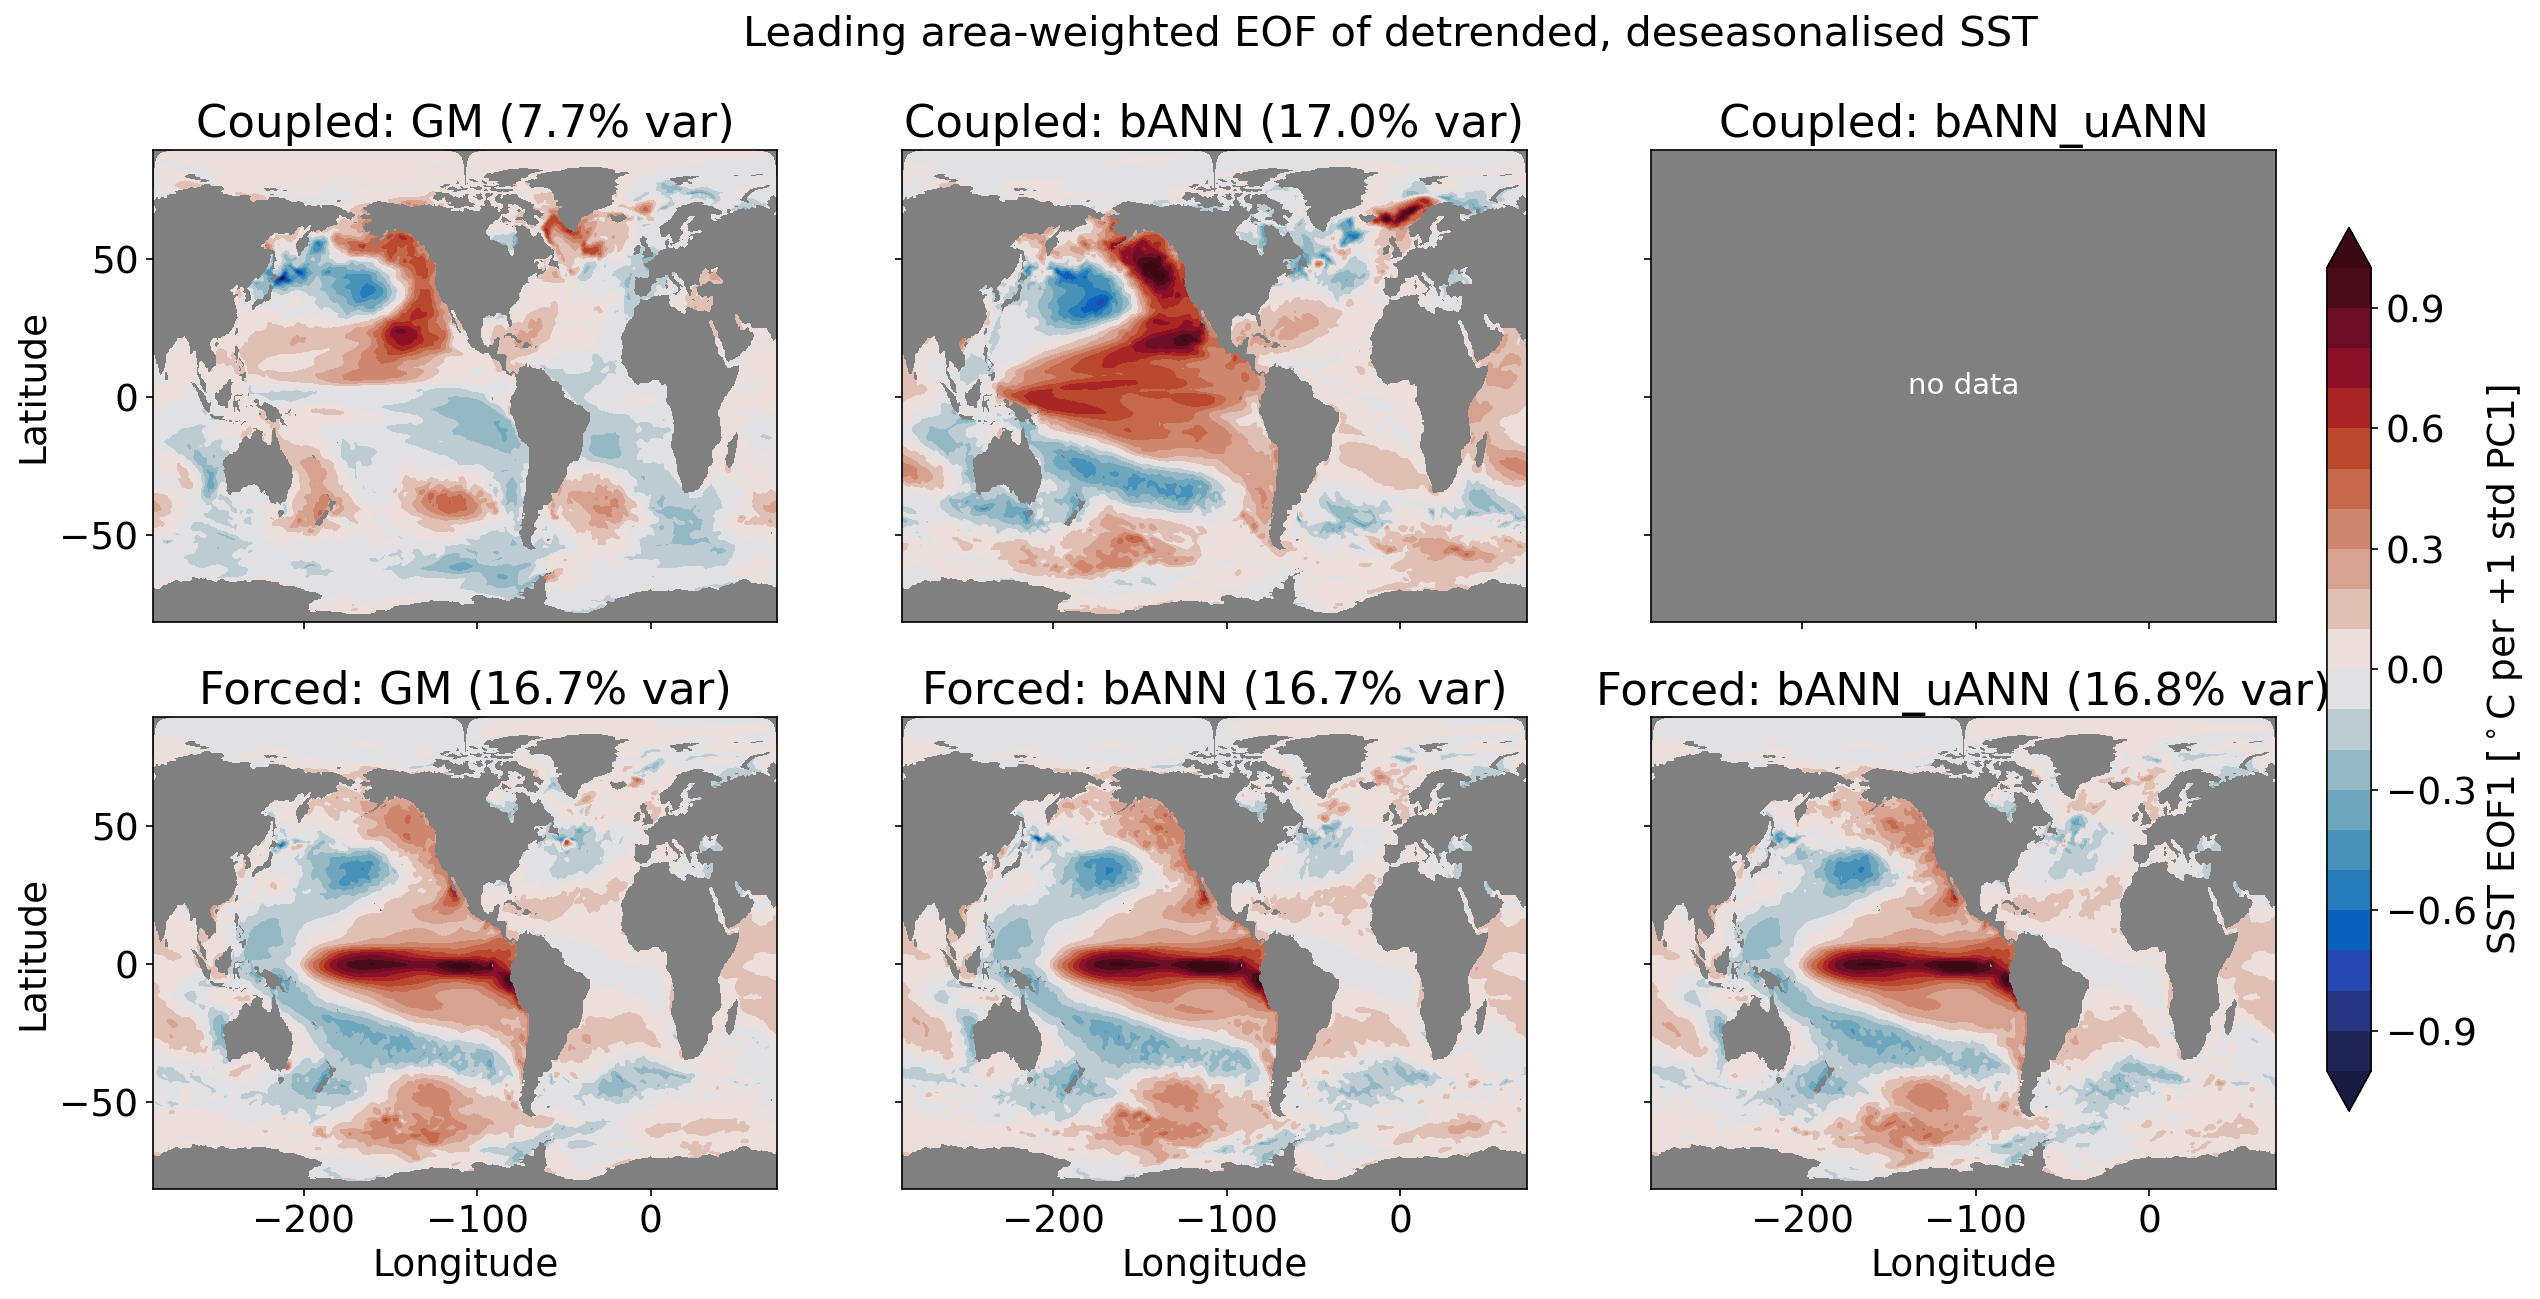

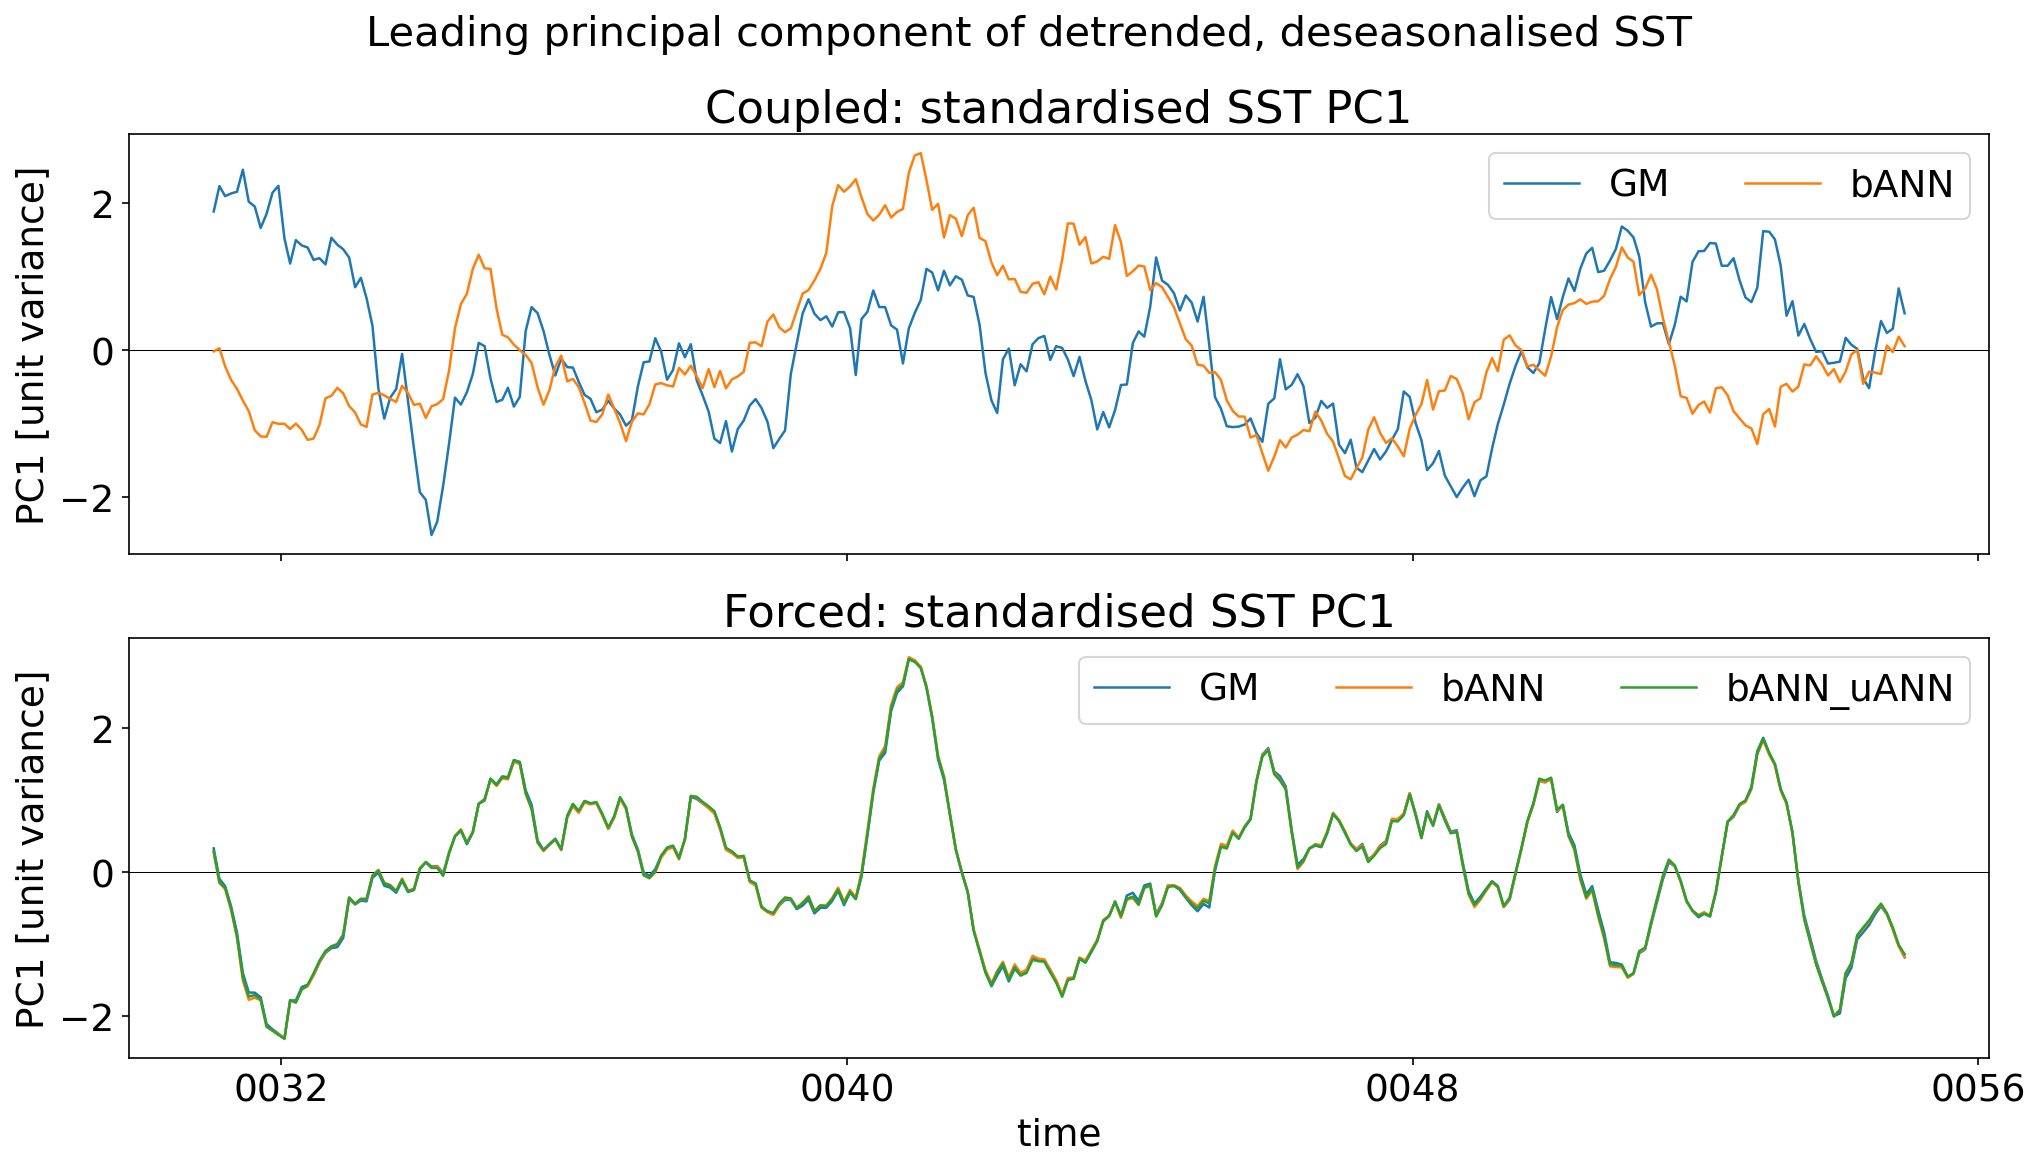

In [4]:
# Leading area-weighted EOF of the detrended, deseasonalised SST anomalies.
# The spatial patterns are orthogonal under the spherical inner product
# (area-weighted); the map shows degC per +1 std of the standardised PC1.
EOF_LEVELS = np.arange(-1.0, 1.05, 0.1)      # degC per +1 std of PC1

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            ds = exps[name].sst_eof1()
            eof = ds['sst_eof1'].where(grd.wet.values > 0)
            ev = float(ds['sst_eof1'].attrs.get('explained_variance', np.nan))
            cf = ax.contourf(grd.geolon, grd.geolat, eof, levels=EOF_LEVELS,
                             cmap=cmocean.cm.balance, extend='both')
            title = f'{regime}: {LABELS[name]} ({100 * ev:.1f}% var)'
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'SST EOF1 [$^\circ$C per +1 std PC1]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'Leading area-weighted EOF of detrended, deseasonalised SST',
             fontsize=20)
plt.show()

# Standardised leading principal component (PC1) time series.
fig, axes = plt.subplots(2, 1, figsize=(16, 8), dpi=150, sharex=True)
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    ax = axes[row]
    ax.axhline(0.0, color='k', lw=0.5)
    for name in names:
        try:
            ds = exps[name].sst_eof1()
            ds['sst_pc1'].plot(ax=ax, lw=1.2, label=LABELS[name])
        except (FileNotFoundError, KeyError):
            pass
    ax.set_title(f'{regime}: standardised SST PC1')
    ax.set_ylabel('PC1 [unit variance]')
    ax.set_xlabel('')
    ax.legend(loc='upper right', ncol=3)
axes[1].set_xlabel('time')
fig.suptitle(r'Leading principal component of detrended, deseasonalised SST',
             fontsize=20)
plt.show()


# 3. NAO (North Atlantic Oscillation)

Following the NCAR/Hurrell definition ("Hurrell North Atlantic Oscillation
(NAO) Index (PC-based)"):

> The principal component (PC)-based indices of the North Atlantic
> Oscillation (NAO) are the time series of the leading Empirical Orthogonal
> Function (EOF) of SLP anomalies over the Atlantic sector, 20-80N, 90W-40E.
> These indices are used to measure the NAO throughout the year, tracking
> the seasonal movements of the Icelandic low and Azores high. Positive
> values of the NAO index are typically associated with stronger-than-average
> westerlies over the middle latitudes, more intense weather systems over
> the North Atlantic and wetter/milder weather over western Europe.

`Experiment.compute_nao` reads monthly sea-level pressure (`PSL`) from the
CAM history, restricts it to the Atlantic sector box, removes the monthly
climatology (deseasonalised anomalies, **no detrending** -- the NAO is an
internal-variability mode, not expected to trend), and computes the leading
EOF weighted by $\sqrt{\cos(\mathrm{lat})}$ (the standard area weighting for
a regular lat/lon grid). The sign convention is fixed so that positive PC1
means a stronger Icelandic low (negative pressure loading near 65N, 20W).

**Observational reference:** `data/ERA5-SLP.nc` (ERA5 monthly mean sea-level
pressure, 1981-2010, already cropped close to the Atlantic sector box) is
put through the exact same EOF recipe directly in this notebook (no
`Experiment` involved, since it is not tied to a model run).

**This is a first pass**, not yet the full Hurrell definition:

- The official index is computed **per calendar month** (or restricted to
  the DJFM season); here a single EOF is fit to the full year-round monthly
  anomaly time series.
- No detrending is applied (deliberate, see above), unlike the SST EOF in
  Section 2.

The NAO is an atmospheric mode, so it does not exist for the **forced**
(ocean-only) experiments -- they are excluded from the plots below rather
than shown as empty "no data" panels.

The first two cells compute/cache the model NAO and the ERA5 NAO
respectively. The third cell plots the spatial pattern -- ERA5 then the
three coupled experiments -- on a North Polar Stereographic map with
coastlines (Cartopy), then the PC time series. ERA5 (1981-2010, Gregorian)
and the model (NoLeap, simulation years) have no shared absolute time axis,
so the PC time series are instead aligned by **years since each record
started** -- convenient for comparing amplitude/variability side by side,
even though a given x position is not the same calendar year across curves.


In [5]:
# Compute (and cache) the NAO pattern / PC for every experiment. Reads raw
# CAM history -> heavy; skips experiments without an interactive atmosphere
# (forced/ocean-only runs).
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_nao()
    except Exception as e:
        print(f'{name} skipped ({e})')


[########################################] | 100% Completed | 20.98 s
[########################################] | 100% Completed | 32.08 s
coupled_bANN_1.0_uANN_1.0 skipped ([Errno 2] No such file or directory: '/glade/derecho/scratch/pavelp/archive/coupled_bANN_1.0_uANN_1.0/atm/hist/coupled_bANN_1.0_uANN_1.0.cam.h0a.0031-01.nc')
forced_CTRL skipped ([Errno 2] No such file or directory: '/glade/derecho/scratch/pavelp/archive/forced_CTRL/atm/hist/forced_CTRL.cam.h0a.0031-01.nc')
forced_bANN_1.0 skipped ([Errno 2] No such file or directory: '/glade/derecho/scratch/pavelp/archive/forced_bANN_1.0/atm/hist/forced_bANN_1.0.cam.h0a.0031-01.nc')
forced_bANN_1.0_uANN_1.0 skipped ([Errno 2] No such file or directory: '/glade/derecho/scratch/pavelp/archive/forced_bANN_1.0_uANN_1.0/atm/hist/forced_bANN_1.0_uANN_1.0.cam.h0a.0031-01.nc')


In [5]:
# Observational reference: leading EOF of ERA5 monthly sea-level pressure
# (1981-2010) over the same Atlantic sector box, following the exact same
# methodology as Experiment.compute_nao (deseasonalised anomalies, no
# detrending, sqrt(cos(lat)) weighting, sign fixed to a stronger Icelandic
# low = positive PC). `data/ERA5-SLP.nc` is a modest single file (already
# cropped close to the NAO box), so this is computed directly here rather
# than through a compute_*/cache step.

def compute_era5_nao():
    ds = xr.open_dataset(os.path.join(REPO, 'data', 'ERA5-SLP.nc'))
    ds = ds.rename({'valid_time': 'time'})
    slp = (ds['msl'].sel(latitude=slice(80, 20), longitude=slice(-90, 40))
           / 100.0)                                       # Pa -> hPa
    slp = slp.load()

    clim = slp.groupby('time.month').mean('time')
    anom = slp.groupby('time.month') - clim                # (time, lat, lon)

    nt, ny, nx = anom.shape
    A = anom.values.reshape(nt, ny * nx)

    coslat = np.cos(np.deg2rad(anom['latitude'].values))
    w = np.sqrt(np.broadcast_to(coslat[:, None], (ny, nx))).reshape(ny * nx)

    mask = np.isfinite(w) & np.isfinite(A).all(axis=0)
    A = A[:, mask]
    w = w[mask]
    A = A - A.mean(axis=0, keepdims=True)

    B = A * w[None, :]
    _, S, Vt = np.linalg.svd(B, full_matrices=False)
    v1 = Vt[0]
    pc_raw = B @ v1
    pc1 = pc_raw / pc_raw.std()
    pattern = (A * pc1[:, None]).mean(axis=0)
    explained = float(S[0] ** 2 / (S ** 2).sum())

    pat_full = np.full(ny * nx, np.nan)
    pat_full[mask] = pattern
    pat2d = pat_full.reshape(ny, nx)

    ilat = int(np.argmin(np.abs(anom['latitude'].values - 65.0)))
    ilon = int(np.argmin(np.abs(anom['longitude'].values - (-20.0))))
    if pat2d[ilat, ilon] > 0:
        pat2d = -pat2d
        pc1 = -pc1

    pattern_da = xr.DataArray(
        pat2d, dims=('lat', 'lon'),
        coords={'lat': anom['latitude'].values, 'lon': anom['longitude'].values},
        name='nao_pattern')
    pattern_da.attrs['explained_variance'] = explained
    pc_da = xr.DataArray(pc1, dims=('time',), coords={'time': anom['time']},
                         name='nao_pc')
    return pattern_da, pc_da


era5_nao_pattern, era5_nao_pc = compute_era5_nao()
print(f'ERA5 NAO: {100 * era5_nao_pattern.attrs["explained_variance"]:.1f}% '
      'variance explained (1981-2010, year-round)')


ERA5 NAO: 34.6% variance explained (1981-2010, year-round)


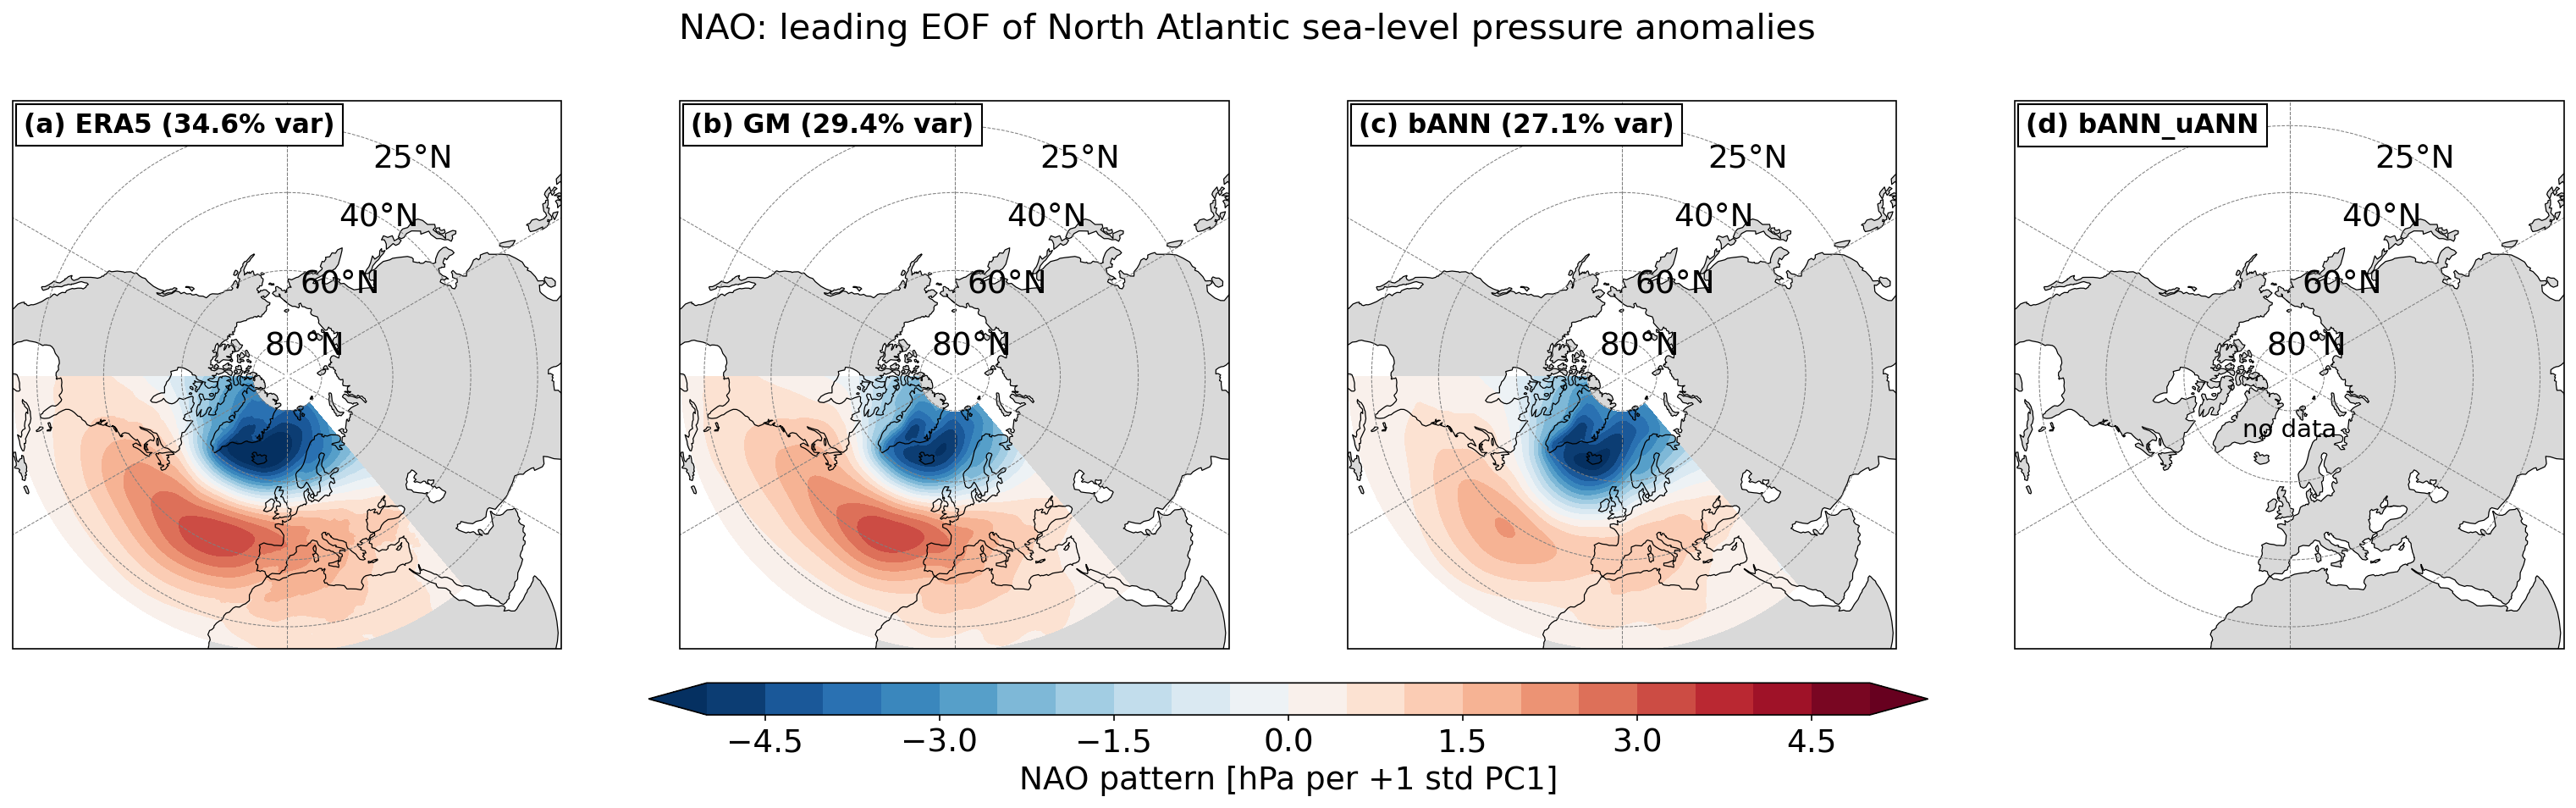

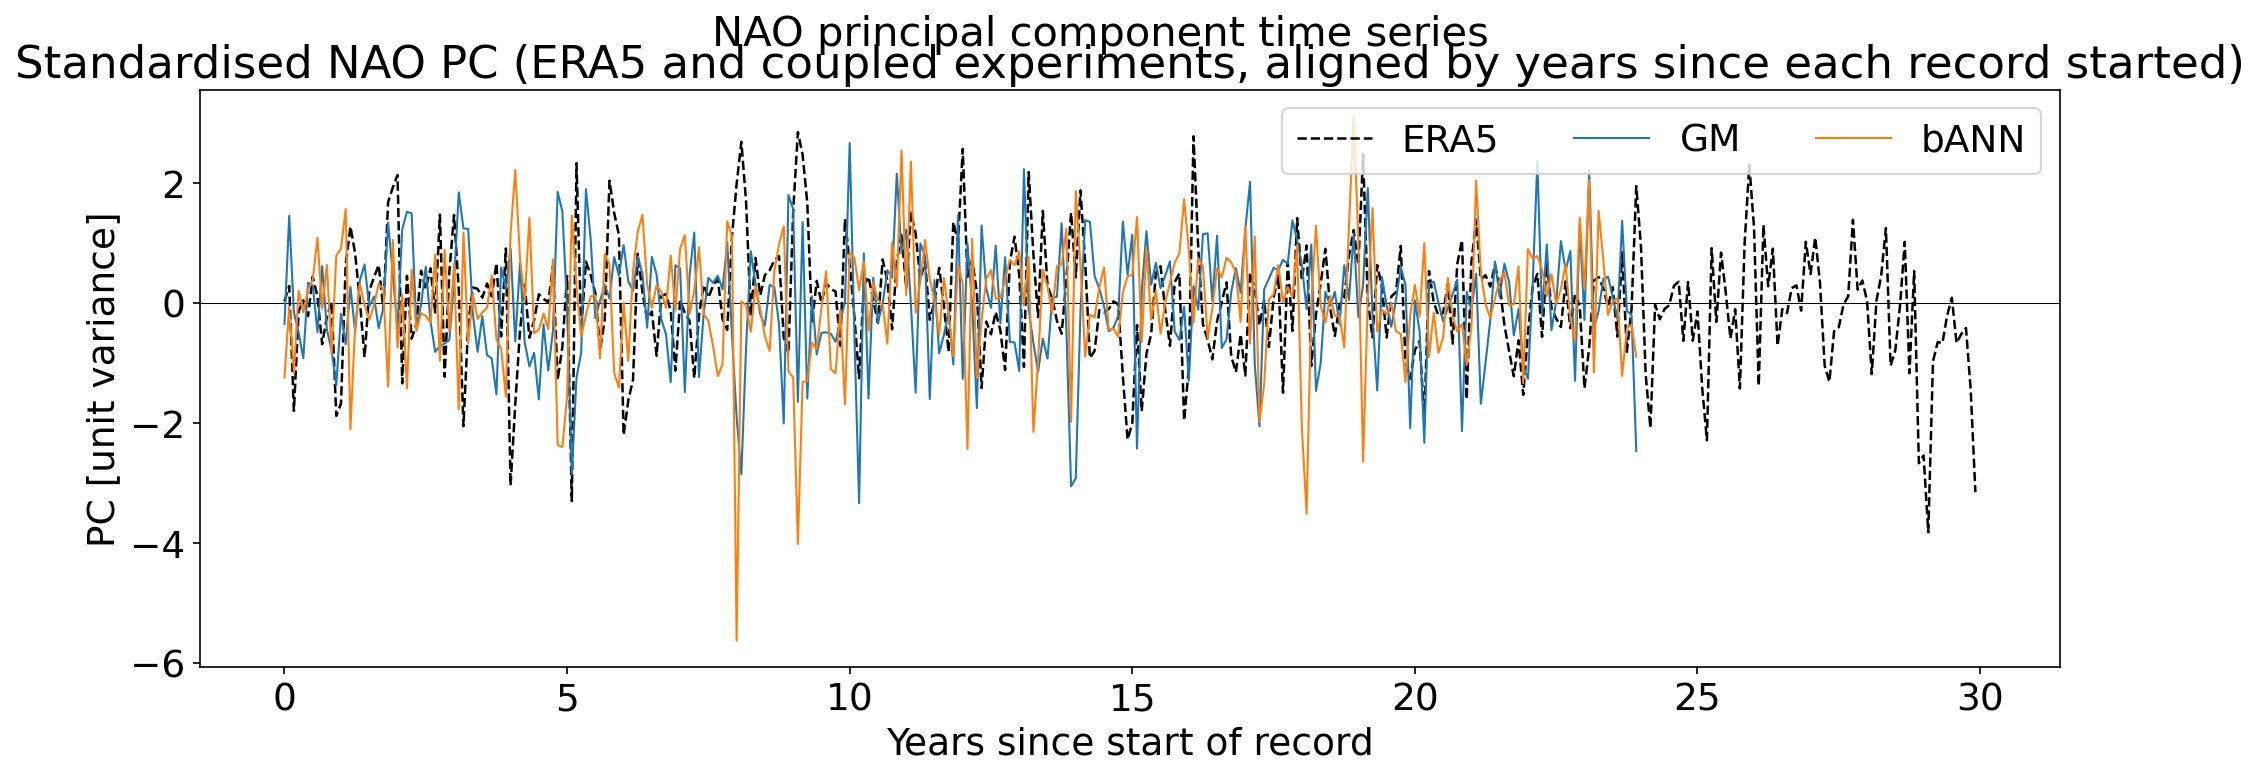

In [6]:
# NAO spatial pattern (leading EOF of North Atlantic SLP anomalies) on a
# North Polar Stereographic map with coastlines, boxed panel labels and a
# shared horizontal colorbar. ERA5 (observational reference) is shown first,
# then the coupled experiments -- the NAO is an atmospheric mode and does
# not exist for the forced (ocean-only) runs.
NAO_LEVELS = np.arange(-5.0, 5.5, 0.5)      # hPa per +1 std of PC1
PANEL_LABELS = ['(a)', '(b)', '(c)', '(d)']

# Each panel is (title label, pattern-getter). ERA5's pattern is already
# computed; the model patterns are fetched lazily inside the loop so a
# missing experiment falls through to the except block below.
panels = [('ERA5', lambda: era5_nao_pattern)]
for name in coupled_names:
    panels.append((LABELS[name], lambda name=name: exps[name].nao()['nao_pattern']))

fig = plt.figure(figsize=(26, 7), dpi=150)
cf = None
for col, (label, get_pattern) in enumerate(panels):
    ax = fig.add_subplot(1, 4, col + 1, projection=ccrs.NorthPolarStereo())
    ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                      linestyle='--', ylocs=[25, 40, 60, 80])
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    try:
        pattern = get_pattern()
        ev = float(pattern.attrs.get('explained_variance', np.nan))
        cf = ax.contourf(pattern['lon'], pattern['lat'], pattern,
                         levels=NAO_LEVELS, cmap='RdBu_r', extend='both',
                         transform=ccrs.PlateCarree())
        title = f'{PANEL_LABELS[col]} {label} ({100 * ev:.1f}% var)'
    except (FileNotFoundError, KeyError):
        ax.text(0.5, 0.4, 'no data', transform=ax.transAxes,
                ha='center', va='center', fontsize=14)
        title = f'{PANEL_LABELS[col]} {label}'
    ax.text(0.02, 0.98, title,
            transform=ax.transAxes, fontsize=15, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='square,pad=0.3', facecolor='white', edgecolor='black'))
if cf is not None:
    fig.colorbar(cf, ax=fig.axes, orientation='horizontal',
                 label='NAO pattern [hPa per +1 std PC1]',
                 extend='both', shrink=0.5, pad=0.05, aspect=40)
fig.suptitle('NAO: leading EOF of North Atlantic sea-level pressure anomalies',
             fontsize=20)
plt.show()

# Standardised NAO principal component time series, ERA5 and the coupled
# experiments together. ERA5 (1981-2010, Gregorian) and the model (NoLeap,
# simulation years) use different calendars/periods, so there is no shared
# absolute time axis; instead every series is plotted against "years since
# its own record started" (monthly data, so month index / 12), which lines
# up the record lengths for convenient visual comparison of amplitude and
# variability even though a given x position is not the same calendar year.
fig, ax = plt.subplots(figsize=(16, 5), dpi=150)
ax.axhline(0.0, color='k', lw=0.5)

years = np.arange(era5_nao_pc.sizes['time']) / 12.0
ax.plot(years, era5_nao_pc.values, lw=1.2, color='k', ls='--', label='ERA5')

for name in coupled_names:
    try:
        pc = exps[name].nao()['nao_pc']
        years = np.arange(pc.sizes['time']) / 12.0
        ax.plot(years, pc.values, lw=1.0, label=LABELS[name])
    except (FileNotFoundError, KeyError):
        pass
ax.set_title('Standardised NAO PC (ERA5 and coupled experiments, aligned by '
             'years since each record started)')
ax.set_ylabel('PC [unit variance]')
ax.set_xlabel('Years since start of record')
ax.legend(loc='upper right', ncol=4)
fig.suptitle('NAO principal component time series', fontsize=20)
plt.show()
